# Data Observatory — Runner Notebook

This notebook implements every operation in the **Runner Catalog**.  
The **Planner agent** (`@data-observatory`) tells you which calls to make and in what order.

**Workflow:**
1. Run **Section 1** (Setup + Functions) once at the start of each session.
2. Run **Section 2** to load your dataset.
3. Ask the Planner: *
4. Paste the `actions_to_run` calls into the matching phase cell and execute.
5. Share the artifact content back with the Planner and repeat for next phase.

All artifacts are saved to the **`artifacts/`** subfolder automatically.

---
## Section 1 — Setup & Runner Functions
Run this section once before anything else.

In [1]:
# -- 1a. Imports & folder setup ------------------------------------------------
import json
import shutil
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RUN_ROOT  = Path(".").resolve()
ARTIFACTS = RUN_ROOT / "artifacts"
PLOTS     = ARTIFACTS / "plots"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print("Run folder:", RUN_ROOT)
print("Artifacts folder:", ARTIFACTS)

Setup complete.
Run folder: C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313
Artifacts folder: C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts


In [2]:
# ── 1b. Internal helpers ──────────────────────────────────────────────────────
def _read(filename):
    """Read an artifact JSON; return {} if it does not exist yet."""
    p = ARTIFACTS / filename
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else {}

def _write(filename, data):
    """Write data to artifacts/<filename>."""
    p = ARTIFACTS / filename
    if isinstance(data, str):
        p.write_text(data, encoding="utf-8")
    else:
        p.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    print(f"  ✓  {p}")

_plot_counter = [0]

def _next_id(prefix):
    _plot_counter[0] += 1
    return f"{prefix}_{_plot_counter[0]:02d}"

def _register_plot(plot_id, filename, op, params):
    registry = _read("05_visual_registry.json")
    registry.setdefault("plots", []).append({
        "id":     plot_id,
        "file":   f"artifacts/plots/{filename}",
        "op":     op,
        "params": {k: v for k, v in params.items() if v is not None},
    })
    _write("05_visual_registry.json", registry)

print("✓ Helpers loaded.")

✓ Helpers loaded.


In [3]:
# ── 1c. OBSERVE functions ─────────────────────────────────────────────────────

def profile_dataset(df):
    data = _read("00_raw_profile.json")
    data.update({
        "rows":             int(df.shape[0]),
        "columns":          int(df.shape[1]),
        "column_names":     df.columns.tolist(),
        "dtypes":           {c: str(t) for c, t in df.dtypes.items()},
        "memory_usage_mb":  round(df.memory_usage(deep=True).sum() / 1e6, 4),
    })
    _write("00_raw_profile.json", data)


def infer_schema(df):
    schema = {}
    for col in df.columns:
        dtype  = str(df[col].dtype)
        nu     = int(df[col].nunique(dropna=True))
        if dtype in ("object", "category"):
            kind = "categorical_low" if nu <= 20 else "categorical_high"
        elif "int" in dtype or "float" in dtype:
            kind = "numeric"
        elif "datetime" in dtype or "timedelta" in dtype:
            kind = "datetime"
        else:
            kind = "other"
        schema[col] = {
            "dtype":         dtype,
            "nunique":       nu,
            "inferred_type": kind,
            "sample_values": [str(v) for v in df[col].dropna().head(5).tolist()],
        }
    data = _read("00_raw_profile.json")
    data["schema"] = schema
    _write("00_raw_profile.json", data)


def missing_report(df):
    total  = len(df)
    report = {
        col: {
            "missing_count": int(df[col].isna().sum()),
            "missing_pct":   round(df[col].isna().sum() / total * 100, 2),
        }
        for col in df.columns
    }
    data = _read("00_raw_profile.json")
    data["missing_report"] = report
    _write("00_raw_profile.json", data)


def duplicates_report(df):
    n_dup = int(df.duplicated().sum())
    data  = _read("00_raw_profile.json")
    data["duplicates_report"] = {
        "total_rows":     int(len(df)),
        "duplicate_rows": n_dup,
        "duplicate_pct":  round(n_dup / max(len(df), 1) * 100, 2),
    }
    _write("00_raw_profile.json", data)


print("✓ OBSERVE functions loaded.")

✓ OBSERVE functions loaded.


In [4]:
# ── 1d. DESCRIBE — statistics functions ──────────────────────────────────────

def numeric_summary(df):
    nums = df.select_dtypes(include="number")
    summary = nums.describe().round(4).to_dict()
    data = _read("04_descriptive_stats.json")
    data["numeric_summary"] = summary
    _write("04_descriptive_stats.json", data)


def categorical_summary(df):
    cats = df.select_dtypes(include=["object", "category"])
    summary = {}
    for col in cats.columns:
        vc = df[col].value_counts(dropna=False)
        summary[col] = {
            "nunique":    int(df[col].nunique()),
            "top_values": {str(k): int(v) for k, v in vc.head(10).items()},
        }
    data = _read("04_descriptive_stats.json")
    data["categorical_summary"] = summary
    _write("04_descriptive_stats.json", data)


def crosstab(df, a, b):
    ct = pd.crosstab(df[a], df[b])
    data = _read("04_descriptive_stats.json")
    data.setdefault("crosstabs", {})[f"{a}_x_{b}"] = ct.to_dict()
    _write("04_descriptive_stats.json", data)


def correlation_matrix(df, method="pearson"):
    """method: 'pearson' | 'spearman' | 'kendall'"""
    nums = df.select_dtypes(include="number")
    corr = nums.corr(method=method).round(4).to_dict()
    data = _read("04_descriptive_stats.json")
    data.setdefault("correlation_matrices", {})[method] = corr
    _write("04_descriptive_stats.json", data)


print("✓ DESCRIBE stat functions loaded.")

✓ DESCRIBE stat functions loaded.


In [6]:
# ── 1e. DESCRIBE — plot functions ─────────────────────────────────────────────

def plot_count(df, x, hue=None):
    pid   = _next_id("count")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.countplot(data=df, x=x, hue=hue, ax=ax)
    ax.set_title(f"Count: {x}" + (f" by {hue}" if hue else ""))
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_count", {"x": x, "hue": hue})


def plot_hist(df, x, groupby=None):
    pid   = _next_id("hist")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    if groupby:
        for grp, sub in df.groupby(groupby):
            sub[x].dropna().plot.hist(bins=30, alpha=0.6, label=str(grp), ax=ax)
        ax.legend(title=groupby)
    else:
        df[x].dropna().plot.hist(bins=30, ax=ax)
    ax.set_xlabel(x)
    ax.set_title(f"Histogram: {x}" + (f" grouped by {groupby}" if groupby else ""))
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_hist", {"x": x, "groupby": groupby})


def plot_box(df, x, y):
    pid   = _next_id("box")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(data=df, x=x, y=y, ax=ax)
    ax.set_title(f"Boxplot: {y} by {x}")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_box", {"x": x, "y": y})


def plot_scatter(df, x, y, hue=None):
    pid   = _next_id("scatter")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=df, x=x, y=y, hue=hue, alpha=0.5, ax=ax)
    ax.set_title(f"Scatter: {x} vs {y}" + (f" (hue={hue})" if hue else ""))
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_scatter", {"x": x, "y": y, "hue": hue})


def plot_heatmap_corr(df, method="pearson"):
    pid   = _next_id("heatmap")
    fname = f"{pid}.png"
    nums  = df.select_dtypes(include="number")
    corr  = nums.corr(method=method)
    size  = max(6, len(corr.columns))
    fig, ax = plt.subplots(figsize=(size, size - 1))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                linewidths=0.5, ax=ax)
    ax.set_title(f"Correlation heatmap ({method})")
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_heatmap_corr", {"method": method})


print("✓ DESCRIBE plot functions loaded.")
print("\n─────────────────────────────────────────")
print("All Runner functions ready. Load your dataset next.")

✓ DESCRIBE plot functions loaded.

─────────────────────────────────────────
All Runner functions ready. Load your dataset next.


---
## Section 2 — Load Dataset
Edit the cell below to point to your file.

In [5]:
# -- Load your dataset ----------------------------------------------------------
# Alternative examples:
# df = pd.read_csv("path/to/file.csv")
# df = pd.read_excel("path/to/file.xlsx")

df = pd.read_csv(r"C:\Users\user\Downloads\blood_cell_anomaly_detection.csv")

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded: 5,880 rows x 36 columns


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


---
## Section 3 — Phase 1: OBSERVE

Ask the Planner:  
> *

Then paste the `actions_to_run` Python calls from the Planner's JSON response into the cell below and run it.

In [8]:
# ── Phase 1: OBSERVE ──────────────────────────────────────────────────────────
# Paste Planner's actions_to_run here, e.g.:
profile_dataset(df)
infer_schema(df)
missing_report(df)
duplicates_report(df)

# Then read artifacts/00_raw_profile.json and share its content with the Planner.

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\00_raw_profile.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\00_raw_profile.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\00_raw_profile.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\00_raw_profile.json


In [9]:
# ── Read & print an artifact (use after each phase) ───────────────────────────
artifact = "00_raw_profile.json"   # ← change as needed
print((ARTIFACTS / artifact).read_text(encoding="utf-8"))

{
  "rows": 5880,
  "columns": 36,
  "column_names": [
    "cell_id",
    "cell_type",
    "anomaly_label",
    "disease_category",
    "cell_diameter_um",
    "nucleus_area_pct",
    "chromatin_density",
    "cytoplasm_ratio",
    "circularity",
    "eccentricity",
    "granularity_score",
    "lobularity_score",
    "membrane_smoothness",
    "cell_area_px",
    "perimeter_px",
    "mean_r",
    "mean_g",
    "mean_b",
    "stain_intensity",
    "patient_age_group",
    "patient_sex",
    "wbc_count_per_ul",
    "rbc_count_millions_per_ul",
    "hemoglobin_g_dl",
    "hematocrit_pct",
    "platelet_count_per_ul",
    "mcv_fl",
    "mchc_g_dl",
    "dataset_source",
    "staining_protocol",
    "microscope_model",
    "magnification_x",
    "image_resolution_px",
    "cytodiffusion_anomaly_score",
    "cytodiffusion_classification_confidence",
    "labeller_confidence_score"
  ],
  "dtypes": {
    "cell_id": "str",
    "cell_type": "str",
    "anomaly_label": "int64",
    "disease_cat

---
## Section 4 — Phase 2: DESCRIBE

Share `artifacts/00_raw_profile.json` with the Planner and say:  
> *

Paste the returned `actions_to_run` calls below.

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\04_descriptive_stats.json


C:\Users\user\AppData\Local\Temp\ipykernel_7500\2742124240.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats = df.select_dtypes(include=["object", "category"])


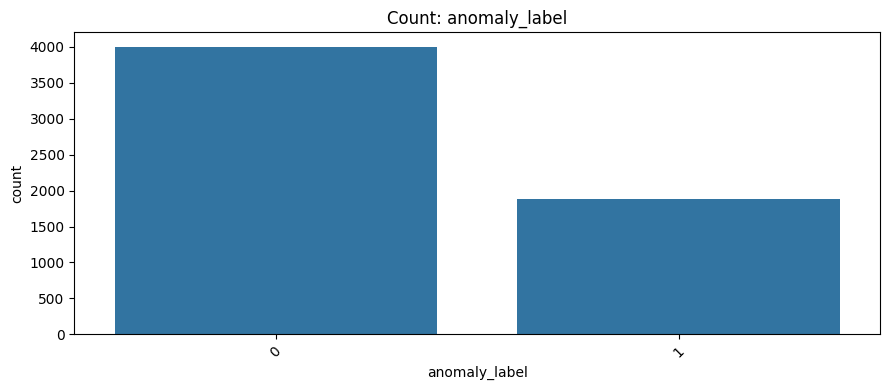

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


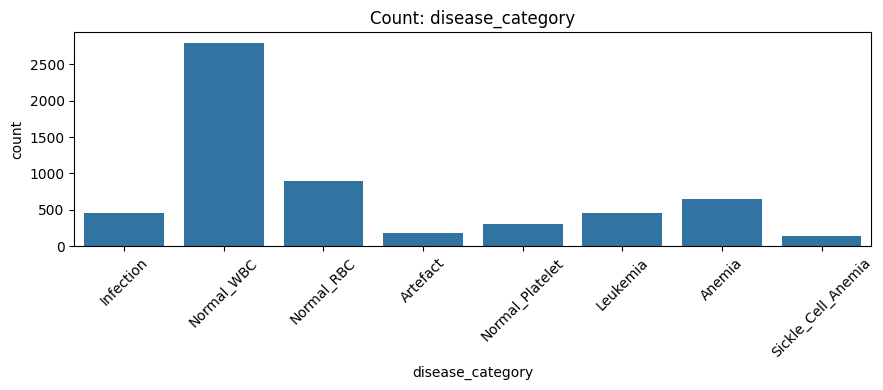

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


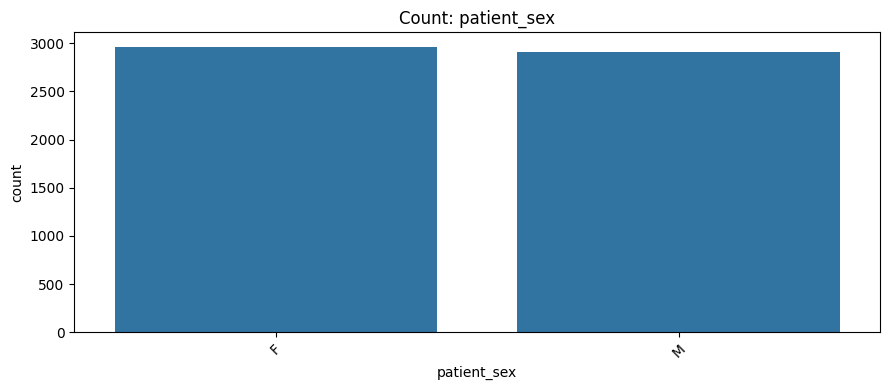

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


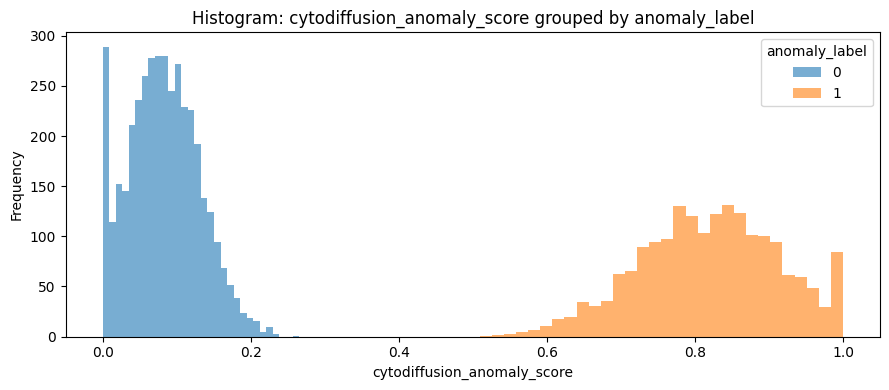

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


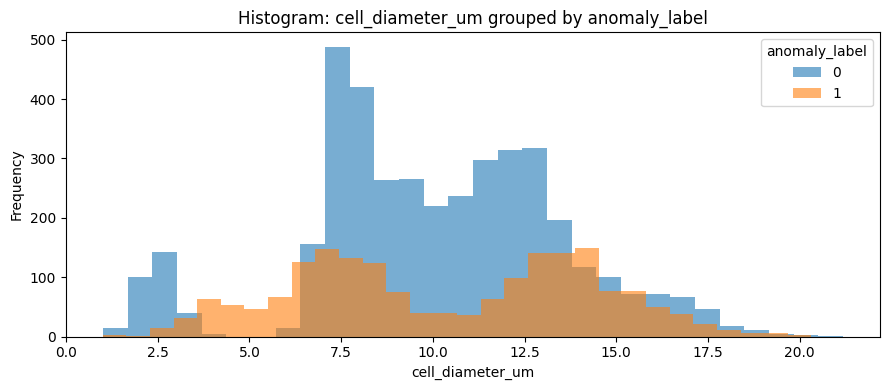

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


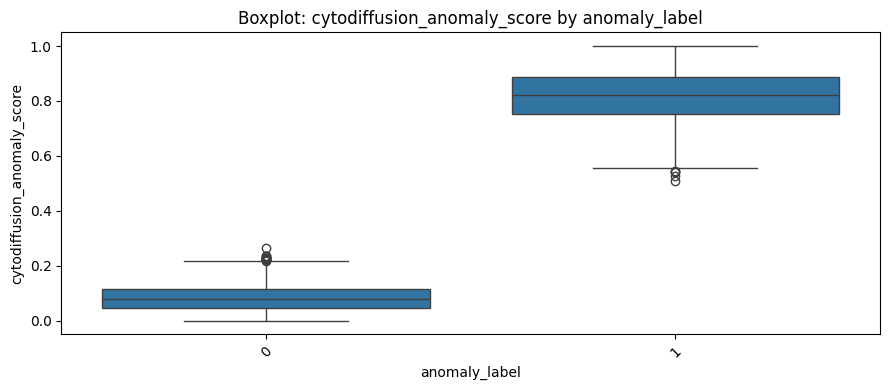

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


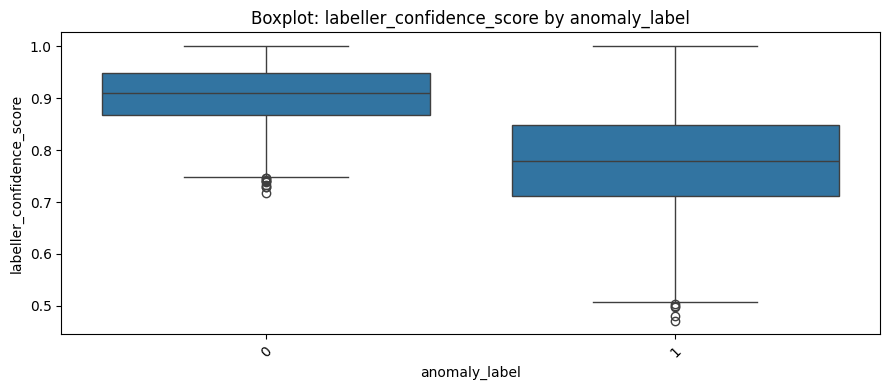

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


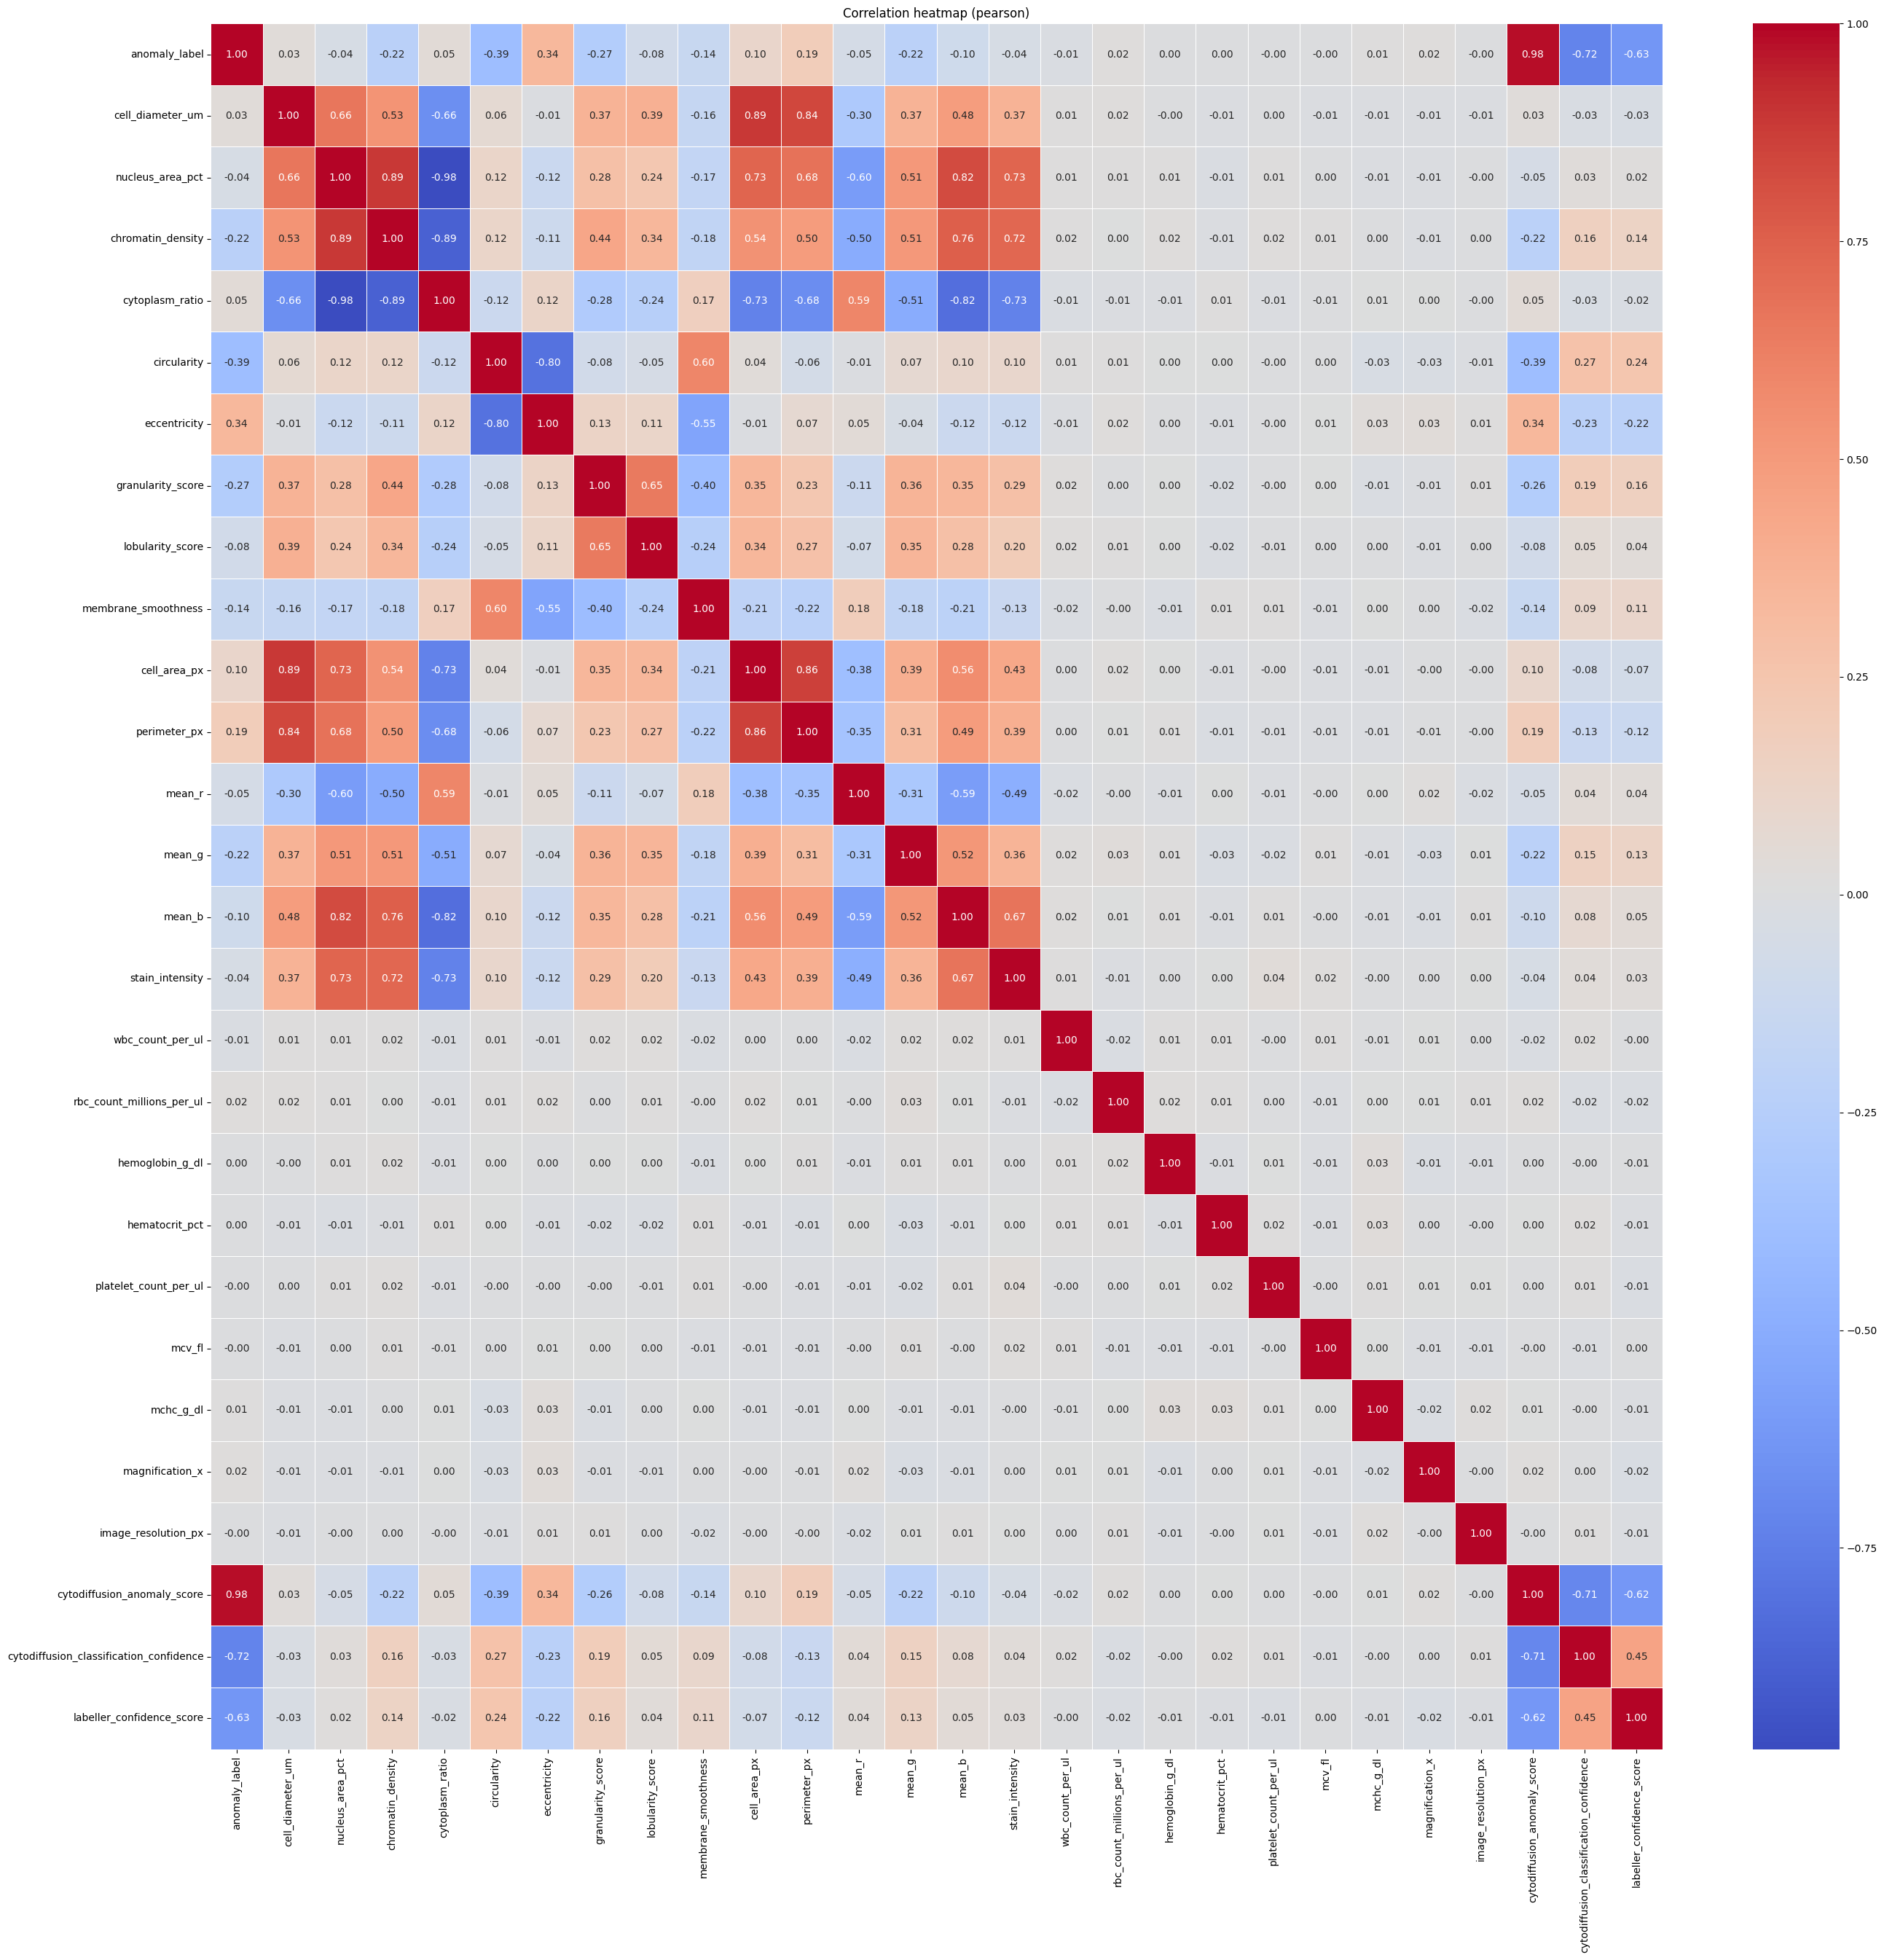

  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\05_visual_registry.json


In [11]:
# -- Phase 2: DESCRIBE ---------------------------------------------------------
numeric_summary(df)
categorical_summary(df)
correlation_matrix(df, method="pearson")
correlation_matrix(df, method="spearman")
crosstab(df, a="cell_type", b="anomaly_label")
crosstab(df, a="disease_category", b="anomaly_label")
plot_count(df, x="anomaly_label")
plot_count(df, x="disease_category")
plot_count(df, x="patient_sex")
plot_hist(df, x="cytodiffusion_anomaly_score", groupby="anomaly_label")
plot_hist(df, x="cell_diameter_um", groupby="anomaly_label")
plot_box(df, x="anomaly_label", y="cytodiffusion_anomaly_score")
plot_box(df, x="anomaly_label", y="labeller_confidence_score")
plot_heatmap_corr(df, method="pearson")

---
## Section 5 — Phase 3: HYPOTHESIZE & CONCLUDE

Share `artifacts/04_descriptive_stats.json` and `artifacts/05_visual_registry.json` with the Planner and say:  
> *

The Planner will write the hypothesis and conclusion artifacts directly.  
If it requests additional operations, paste them below.

In [6]:
# -- Phase 3: HYPOTHESIZE & CONCLUDE + snapshot + tests + HTML -----------------
import html as html_lib
from scipy import stats

def snapshot_current_run(label="before_next_dataset"):
    src = ARTIFACTS
    if not src.exists():
        print("No artifacts folder found yet. Nothing to snapshot.")
        return None

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    snapshots = RUN_ROOT / "snapshots"
    snapshots.mkdir(parents=True, exist_ok=True)
    dst = snapshots / f"snapshot_{label}_{ts}"
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print("Snapshot created:", dst.resolve())
    return dst


def write_report_html():
    md_path = ARTIFACTS / "report.md"
    html_path = ARTIFACTS / "report.html"
    if not md_path.exists():
        print("report.md not found; skipping HTML generation.")
        return None

    md_text = md_path.read_text(encoding="utf-8")
    body = html_lib.escape(md_text)
    html_doc = (
        "<!doctype html>\n"
        "<html lang=\"en\">\n"
        "<head>\n"
        "  <meta charset=\"utf-8\" />\n"
        "  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\" />\n"
        "  <title>Run Report</title>\n"
        "  <style>body{font-family:Consolas,monospace;background:#f8f8f8;color:#222;margin:0;padding:20px;}"
        "pre{white-space:pre-wrap;word-wrap:break-word;background:#fff;border:1px solid #ddd;padding:16px;border-radius:8px;}"
        "</style>\n"
        "</head>\n"
        "<body>\n"
        "  <h1>Reproducible Data Observatory Report</h1>\n"
        "  <pre>" + body + "</pre>\n"
        "</body>\n"
        "</html>\n"
    )
    html_path.write_text(html_doc, encoding="utf-8")
    print("  ✓", html_path)
    return html_path


def run_phase3_tests(df_input):
    required_cols = [
        "anomaly_label",
        "cytodiffusion_anomaly_score",
        "cytodiffusion_classification_confidence",
        "labeller_confidence_score",
        "disease_category",
        "cell_type",
    ]
    missing_cols = [c for c in required_cols if c not in df_input.columns]
    if missing_cols:
        print("Missing columns for tests:", ", ".join(missing_cols))
        return None

    out = {
        "metadata": {
            "rows": int(len(df_input)),
            "group_counts": {
                "0": int((df_input["anomaly_label"] == 0).sum()),
                "1": int((df_input["anomaly_label"] == 1).sum())
            }
        },
        "tests": {}
    }

    g0 = df_input[df_input["anomaly_label"] == 0]
    g1 = df_input[df_input["anomaly_label"] == 1]

    for col in [
        "cytodiffusion_anomaly_score",
        "cytodiffusion_classification_confidence",
        "labeller_confidence_score",
    ]:
        a = g0[col].dropna()
        b = g1[col].dropna()
        lev_stat, lev_p = stats.levene(a, b, center="median")
        mw_stat, mw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        t_stat, t_p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")

        out["tests"][f"group_diff_{col}"] = {
            "n_group_0": int(a.shape[0]),
            "n_group_1": int(b.shape[0]),
            "levene": {
                "statistic": float(lev_stat),
                "p_value": float(lev_p)
            },
            "mann_whitney_u": {
                "statistic": float(mw_stat),
                "p_value": float(mw_p)
            },
            "welch_t_test": {
                "statistic": float(t_stat),
                "p_value": float(t_p)
            }
        }

    ct_disease = pd.crosstab(df_input["disease_category"], df_input["anomaly_label"])
    chi2_d, p_d, dof_d, _ = stats.chi2_contingency(ct_disease)
    out["tests"]["chi2_disease_category_x_anomaly_label"] = {
        "dof": int(dof_d),
        "chi2": float(chi2_d),
        "p_value": float(p_d)
    }

    ct_cell = pd.crosstab(df_input["cell_type"], df_input["anomaly_label"])
    chi2_c, p_c, dof_c, _ = stats.chi2_contingency(ct_cell)
    out["tests"]["chi2_cell_type_x_anomaly_label"] = {
        "dof": int(dof_c),
        "chi2": float(chi2_c),
        "p_value": float(p_c)
    }

    _write("08_tests.json", out)
    return out


required = ["04_descriptive_stats.json", "05_visual_registry.json"]
outputs = ["06_hypotheses_log.json", "07_conclusions.json", "report.md", "report.html", "08_tests.json"]

missing_required = [f for f in required if not (ARTIFACTS / f).exists()]
if missing_required:
    print("Missing required artifacts for Phase 3:", ", ".join(missing_required))
else:
    print("Phase 3 prerequisites: OK")

if (ARTIFACTS / "report.md").exists():
    write_report_html()

if "df" in globals():
    run_phase3_tests(df)
else:
    print("DataFrame df not found in kernel; skipping tests.")

for name in required + outputs:
    path = ARTIFACTS / name
    print(f"- {name}: {'OK' if path.exists() else 'MISSING'}")

print("\nTip: run snapshot_current_run() before changing dataset or prompts.")

Phase 3 prerequisites: OK
  ✓ C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\report.html
  ✓  C:\Users\user\Desktop\Lab 1\runs\blood_cell_anomaly_20260313\artifacts\08_tests.json
- 04_descriptive_stats.json: OK
- 05_visual_registry.json: OK
- 06_hypotheses_log.json: OK
- 07_conclusions.json: OK
- report.md: OK
- report.html: OK
- 08_tests.json: OK

Tip: run snapshot_current_run() before changing dataset or prompts.
